# Task 5: Robustness Under Video Corruption


- Uses the same Transformer architecture used in the Kaggle notebook.
- Loads model weights from: `/Users/ssweeti/Desktop/anomaly_detection_proejct3/transformer_model/model.pth`
- Uses local feature files under `saved_features`.

In [ ]:
import sys
from pathlib import Path

VENV_PY = ROOT / ".venv" / "bin" / "python"

print("Python executable:", sys.executable)
print("Expected venv python:", str(VENV_PY))

if Path(sys.executable).resolve() != VENV_PY.resolve():
    raise RuntimeError(
        "Wrong kernel selected. Switch the notebook kernel/interpreter to the project venv at: "
        + str(VENV_PY)
    )

print("Kernel OK")

Python executable: /Users/ssweeti/Desktop/anomaly_detection_proejct3/.venv/bin/python
Expected venv python: /Users/ssweeti/Desktop/anomaly_detection_proejct3/.venv/bin/python
Kernel OK


In [ ]:
# Imports (all modules used )
import os
import math
import random
import copy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)

Device: cpu
numpy: 2.0.2
pandas: 2.3.3
torch: 2.8.0


In [ ]:
# Local paths (from top config cell)
FEATURE_DIR = ROOT / "saved_features"
MODEL_PATH = ROOT / "task1" / "model.pth"

assert FEATURE_DIR.exists(), f"Missing feature dir: {FEATURE_DIR}"
assert MODEL_PATH.exists(), f"Missing model path: {MODEL_PATH}"

print("Feature dir:", FEATURE_DIR)
print("Model path:", MODEL_PATH)

Feature dir: /Users/ssweeti/Desktop/anomaly_detection_proejct3/saved_features
Model path: /Users/ssweeti/Desktop/anomaly_detection_proejct3/transformer_model/model.pth


In [ ]:
# Load local feature tensors
train_features = np.load(FEATURE_DIR / "train_features_full.npy")
val_features   = np.load(FEATURE_DIR / "val_features_full.npy")
test_features  = np.load(FEATURE_DIR / "test_features_full.npy")

val_labels  = np.load(FEATURE_DIR / "val_labels.npy")
test_labels = np.load(FEATURE_DIR / "test_labels.npy")

mean = np.load(FEATURE_DIR / "train_mean.npy")
std  = np.load(FEATURE_DIR / "train_std.npy")

# same normalization as main notebook
train_features = (train_features - mean) / std
val_features   = (val_features   - mean) / std
test_features  = (test_features  - mean) / std

print("train:", train_features.shape)
print("val:", val_features.shape, val_labels.shape)
print("test:", test_features.shape, test_labels.shape)

train: (862346, 2048)
val: (300000, 2048) (300000,)
test: (384714, 2048) (384714,)


In [ ]:

class TransformerAE(nn.Module):
    def __init__(self, input_dim=2048, d_model=256):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.decoder = nn.Sequential(
            nn.Linear(d_model, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.transformer(x)
        return self.decoder(x)


model = TransformerAE().to(device)
state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()
print("Loaded model weights successfully")

Loaded model weights successfully


##  Collect 5 diverse test sequences (task tags)

creating test sequence as said

In [ ]:
WINDOW = 8
STRIDE = 5
SEQ_LEN = 40000  # per condition subset, keeps runtime manageable

condition_anchors = {
    "rain": 0,
    "fog": 60000,
    "nighttime": 120000,
    "crowd_occlusion": 180000,
    "camera_pan_zoom": 240000,
}

def pick_segment_with_both_classes(features, labels, anchor, seq_len, scan_step=5000, max_tries=80):
    n = len(features)
    base = max(0, min(anchor, n - seq_len))

    for t in range(max_tries):
        direction = -1 if t % 2 else 1
        hop = (t // 2) * scan_step
        start = max(0, min(base + direction * hop, n - seq_len))
        end = start + seq_len
        seg = labels[start:end]
        if np.any(seg == 0) and np.any(seg == 1):
            return start, end

    return 0, min(seq_len, n)

condition_sequences = {}
condition_rows = []
for name, anchor in condition_anchors.items():
    s, e = pick_segment_with_both_classes(test_features, test_labels, anchor, SEQ_LEN)
    seg_labels = test_labels[s:e]
    condition_sequences[name] = {
        "features": test_features[s:e],
        "labels": seg_labels,
    }

    condition_rows.append({
        "condition": name,
        "start_idx": s,
        "num_frames": int(e - s),
        "anomaly_rate": float(seg_labels.mean()),
        "has_both_classes": bool(np.any(seg_labels == 0) and np.any(seg_labels == 1)),
    })

pd.DataFrame(condition_rows)

,condition,start_idx,num_frames,anomaly_rate,has_both_classes
0,rain,0,40000,0.000875,True
1,fog,60000,40000,0.108500,True
2,nighttime,120000,40000,0.004900,True
3,crowd_occlusion,175000,40000,0.000675,True
4,camera_pan_zoom,240000,40000,0.006200,True


## Corruption synthesis functions

Implements requested corruptions with varying strengths and support for both individual and combined corruptions.

In [ ]:
def apply_rain_snow_overlay(x, opacity=0.2, snow=False):
    # feature-space proxy: sparse streak/speckle additive perturbation
    x = x.copy()
    mask_prob = 0.08 if not snow else 0.15
    mask = (np.random.rand(*x.shape) < mask_prob).astype(np.float32)
    noise = np.random.normal(0.0, 1.0, size=x.shape).astype(np.float32)
    return x + opacity * mask * noise


def apply_gaussian_blur_proxy(x, sigma=1.0):
    # feature-space proxy for blur: attenuate high-frequency/detail energy
    x = x.copy()
    alpha = min(max(sigma / 3.0, 0.0), 1.0)
    frame_mean = x.mean(axis=1, keepdims=True)
    return (1.0 - 0.6 * alpha) * x + (0.6 * alpha) * frame_mean


def apply_jpeg_compression_proxy(x, quality=80):
    # lower quality => stronger quantization
    x = x.copy()
    q = np.clip(quality, 20, 100)
    step = 0.02 + (100 - q) / 100.0 * 0.20
    return np.round(x / step) * step


def apply_brightness_shift_proxy(x, shift_ratio=0.2):
    # +/- 40% requested; shift_ratio in [-0.4, 0.4]
    x = x.copy()
    return x * (1.0 + shift_ratio)


def apply_corruption(x, corruption_name, strength):
    if corruption_name == "rain":
        return apply_rain_snow_overlay(x, opacity=strength, snow=False)
    if corruption_name == "snow":
        return apply_rain_snow_overlay(x, opacity=strength, snow=True)
    if corruption_name == "blur":
        return apply_gaussian_blur_proxy(x, sigma=strength)
    if corruption_name == "jpeg":
        return apply_jpeg_compression_proxy(x, quality=int(strength))
    if corruption_name == "brightness":
        return apply_brightness_shift_proxy(x, shift_ratio=strength)
    raise ValueError(f"Unknown corruption: {corruption_name}")


def apply_corruption_combo(x, combo_spec):
    out = x.copy()
    for name, strength in combo_spec:
        out = apply_corruption(out, name, strength)
    return out

In [ ]:
class SequenceDataset(Dataset):
    def __init__(self, features, labels, window=8, stride=5):
        self.features = features
        self.labels = labels
        self.window = window
        self.stride = stride
        self.length = (len(features) - window) // stride

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        start = idx * self.stride
        seq = self.features[start:start+self.window]
        y = self.labels[start:start+self.window].max()
        return torch.tensor(seq, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


def score_model(model_obj, features, labels, window=8, stride=5, batch_size=256):
    ds = SequenceDataset(features, labels, window=window, stride=stride)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    scores, ys = [], []
    model_obj.eval()
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            out = model_obj(xb)
            frame_mse = ((out - xb) ** 2).mean(dim=2)
            sc = frame_mse.max(dim=1)[0]
            scores.append(sc.cpu().numpy())
            ys.append(yb.numpy())

    scores = np.concatenate(scores)
    ys = np.concatenate(ys)
    auc = roc_auc_score(ys, scores) if len(np.unique(ys)) > 1 else np.nan
    return scores, ys, auc


def compute_fpr_for_normals(scores, ys, threshold):
    normal_mask = ys == 0
    if normal_mask.sum() == 0:
        return np.nan
    return float((scores[normal_mask] > threshold).mean())

In [ ]:
# Baseline evaluation on each condition subset
baseline_rows = []
condition_cache = {}

for cond, payload in condition_sequences.items():
    feats = payload["features"]
    labs = payload["labels"]
    scores, ys, auc = score_model(model, feats, labs, window=WINDOW, stride=STRIDE)

    # Keep only conditions with both classes for AUC-based comparisons.
    if len(np.unique(ys)) < 2:
        continue

    threshold = np.percentile(scores[ys == 0], 95) if np.any(ys == 0) else np.nan
    fpr = compute_fpr_for_normals(scores, ys, threshold) if not np.isnan(threshold) else np.nan

    condition_cache[cond] = {
        "clean_scores": scores,
        "clean_labels": ys,
        "clean_auc": auc,
        "threshold": threshold,
    }

    baseline_rows.append({
        "condition": cond,
        "clean_auc": auc,
        "clean_fpr@p95": fpr,
        "n_sequences": len(ys),
    })

baseline_df = pd.DataFrame(baseline_rows).sort_values("condition")
baseline_df.round(4)

,condition,clean_auc,clean_fpr@p95,n_sequences
4,camera_pan_zoom,0.9839,0.0501,7998
3,crowd_occlusion,0.9987,0.0501,7998
1,fog,0.3582,0.0501,7998
2,nighttime,0.6766,0.0501,7998
0,rain,0.8264,0.0501,7998


In [ ]:
# Individual corruption settings requested in task
corruption_grid = {
    "rain": [0.15, 0.30, 0.45],
    "snow": [0.15, 0.30, 0.45],
    "blur": [1.0, 2.0, 3.0],
    "jpeg": [80, 50, 20],
    "brightness": [-0.40, 0.0, 0.40],
}

rows = []
for cond, payload in condition_sequences.items():
    if cond not in condition_cache:
        continue
    clean_auc = condition_cache[cond]["clean_auc"]
    clean_thr = condition_cache[cond]["threshold"]

    for corr_name, strengths in corruption_grid.items():
        for s in strengths:
            corr_feats = apply_corruption(payload["features"], corr_name, s)
            scores, ys, auc = score_model(model, corr_feats, payload["labels"], window=WINDOW, stride=STRIDE)
            fpr = compute_fpr_for_normals(scores, ys, clean_thr)
            drop_pct = 100.0 * (clean_auc - auc) / max(clean_auc, 1e-8)

            rows.append({
                "condition": cond,
                "corruption": corr_name,
                "strength": s,
                "auc": auc,
                "auc_drop_pct_vs_clean": drop_pct,
                "fpr_under_corruption": fpr,
            })

individual_df = pd.DataFrame(rows)
individual_df.head(20)

,condition,corruption,strength,auc,auc_drop_pct_vs_clean,fpr_under_corruption
0,rain,rain,0.15,0.824886,0.183183,0.066107
1,rain,rain,0.30,0.810328,1.944770,0.092776
2,rain,rain,0.45,0.827196,-0.096412,0.114436
3,rain,snow,0.15,0.821961,0.537153,0.077501
4,rain,snow,0.30,0.815598,1.307073,0.107925
5,rain,snow,0.45,0.805024,2.586599,0.113434
6,rain,blur,1.00,0.832398,-0.725845,0.501690
7,rain,blur,2.00,0.831510,-0.618415,1.000000
8,rain,blur,3.00,0.831476,-0.614283,1.000000
9,rain,jpeg,80.00,0.829678,-0.396667,0.052085


In [ ]:
# Rank corruptions by overall impact (mean AUC drop across conditions & strengths)
impact_rank_df = (
    individual_df.groupby("corruption", as_index=False)["auc_drop_pct_vs_clean"].mean()
    .sort_values("auc_drop_pct_vs_clean", ascending=False)
    .rename(columns={"auc_drop_pct_vs_clean": "mean_auc_drop_pct"})
)
impact_rank_df

,corruption,mean_auc_drop_pct
4,snow,-0.038927
1,brightness,-0.101362
3,rain,-0.127096
2,jpeg,-0.366162
0,blur,-6.595573


In [ ]:
combo_specs = {
    "rain+blur": [("rain", 0.35), ("blur", 2.5)],
    "fog_proxy+jpeg": [("brightness", -0.25), ("jpeg", 30)],
    "night_proxy+blur+jpeg": [("brightness", -0.35), ("blur", 3.0), ("jpeg", 20)],
    "occlusion_proxy+rain": [("snow", 0.45), ("rain", 0.30)],
    "max_corruption": [("brightness", -0.40), ("blur", 3.0), ("jpeg", 20), ("snow", 0.45)],
}

combo_rows = []
for cond, payload in condition_sequences.items():
    if cond not in condition_cache:
        continue
    clean_auc = condition_cache[cond]["clean_auc"]
    clean_thr = condition_cache[cond]["threshold"]

    for combo_name, spec in combo_specs.items():
        corr_feats = apply_corruption_combo(payload["features"], spec)
        scores, ys, auc = score_model(model, corr_feats, payload["labels"], window=WINDOW, stride=STRIDE)
        fpr = compute_fpr_for_normals(scores, ys, clean_thr)
        drop_pct = 100.0 * (clean_auc - auc) / max(clean_auc, 1e-8)

        combo_rows.append({
            "condition": cond,
            "combo": combo_name,
            "auc": auc,
            "auc_drop_pct_vs_clean": drop_pct,
            "fpr_under_corruption": fpr,
        })

combo_df = pd.DataFrame(combo_rows)
combo_df

,condition,combo,auc,auc_drop_pct_vs_clean,fpr_under_corruption
0,rain,rain+blur,0.785936,4.896357,1.000000
1,rain,fog_proxy+jpeg,0.814323,1.461332,0.011769
2,rain,night_proxy+blur+jpeg,0.857826,-3.802768,1.000000
3,rain,occlusion_proxy+rain,0.791377,4.238000,0.118693
4,rain,max_corruption,0.863050,-4.434956,0.999374
5,fog,rain+blur,0.515778,-43.986750,1.000000
6,fog,fog_proxy+jpeg,0.302609,15.522442,0.017970
7,fog,night_proxy+blur+jpeg,0.394544,-10.142556,1.000000
8,fog,occlusion_proxy+rain,0.385580,-7.640051,0.162712
9,fog,max_corruption,0.456288,-27.379274,0.986944


## Input denoiser before anomaly detector

Train a compact denoiser on synthetic corruptions, then evaluate AUC recovery on corrupted sets.

In [ ]:
class SmallDenoiser(nn.Module):
    def __init__(self, dim=2048, hidden=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim),
        )

    def forward(self, x):
        # residual denoising
        return x + self.net(x)


def make_synthetic_corrupted_batch(clean_batch_np):
    x = clean_batch_np.copy()
    # randomly stack 1-3 corruptions
    k = np.random.randint(1, 4)
    choices = ["rain", "snow", "blur", "jpeg", "brightness"]
    picked = np.random.choice(choices, size=k, replace=False)

    for c in picked:
        if c in ["rain", "snow"]:
            s = np.random.uniform(0.1, 0.45)
        elif c == "blur":
            s = np.random.uniform(1.0, 3.0)
        elif c == "jpeg":
            s = np.random.choice([20, 30, 50, 80])
        else:
            s = np.random.uniform(-0.4, 0.4)
        x = apply_corruption(x, c, s)
    return x


# train denoiser on a manageable subset
subset_n = min(120000, len(train_features))
train_subset = train_features[:subset_n]

denoiser = SmallDenoiser(dim=train_subset.shape[1]).to(device)
opt = torch.optim.Adam(denoiser.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

batch_size = 512
epochs = 3

denoiser.train()
for ep in range(epochs):
    perm = np.random.permutation(subset_n)
    total_loss = 0.0
    n_steps = 0

    for i in range(0, subset_n, batch_size):
        idx = perm[i:i+batch_size]
        clean = train_subset[idx].astype(np.float32)
        noisy = make_synthetic_corrupted_batch(clean).astype(np.float32)

        clean_t = torch.from_numpy(clean).to(device)
        noisy_t = torch.from_numpy(noisy).to(device)

        pred = denoiser(noisy_t)
        loss = loss_fn(pred, clean_t)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += float(loss.item())
        n_steps += 1

    print(f"Denoiser epoch {ep+1}/{epochs} | loss={total_loss/max(n_steps,1):.6f}")

Denoiser epoch 1/3 | loss=0.080749
Denoiser epoch 2/3 | loss=0.070722
Denoiser epoch 3/3 | loss=0.051333


In [ ]:
def score_with_denoiser(base_model, denoiser_model, features, labels, window=8, stride=5, batch_size=256):
    ds = SequenceDataset(features, labels, window=window, stride=stride)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    scores, ys = [], []
    base_model.eval()
    denoiser_model.eval()

    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            b, t, d = xb.shape
            flat = xb.reshape(b * t, d)
            den = denoiser_model(flat).reshape(b, t, d)

            out = base_model(den)
            frame_mse = ((out - den) ** 2).mean(dim=2)
            sc = frame_mse.max(dim=1)[0]

            scores.append(sc.cpu().numpy())
            ys.append(yb.numpy())

    scores = np.concatenate(scores)
    ys = np.concatenate(ys)
    auc = roc_auc_score(ys, scores) if len(np.unique(ys)) > 1 else np.nan
    return scores, ys, auc


denoiser_rows = []
for cond, payload in condition_sequences.items():
    if cond not in condition_cache:
        continue
    for combo_name in ["rain+blur", "fog_proxy+jpeg", "night_proxy+blur+jpeg", "max_corruption"]:
        corr_feats = apply_corruption_combo(payload["features"], combo_specs[combo_name])

        _, ys_b, auc_before = score_model(model, corr_feats, payload["labels"], window=WINDOW, stride=STRIDE)
        _, ys_a, auc_after  = score_with_denoiser(model, denoiser, corr_feats, payload["labels"], window=WINDOW, stride=STRIDE)

        denoiser_rows.append({
            "condition": cond,
            "combo": combo_name,
            "auc_before_denoiser": auc_before,
            "auc_after_denoiser": auc_after,
            "auc_recovery": auc_after - auc_before,
        })

denoiser_df = pd.DataFrame(denoiser_rows)
denoiser_df

,condition,combo,auc_before_denoiser,auc_after_denoiser,auc_recovery
0,rain,rain+blur,0.818660,0.459417,-0.359243
1,rain,fog_proxy+jpeg,0.814323,0.435332,-0.378991
2,rain,night_proxy+blur+jpeg,0.857826,0.446305,-0.411521
3,rain,max_corruption,0.826081,0.484640,-0.341441
4,fog,rain+blur,0.523280,0.400045,-0.123235
5,fog,fog_proxy+jpeg,0.302609,0.477887,0.175278
6,fog,night_proxy+blur+jpeg,0.394544,0.421661,0.027117
7,fog,max_corruption,0.443048,0.389421,-0.053627
8,nighttime,rain+blur,0.676097,0.562739,-0.113358
9,nighttime,fog_proxy+jpeg,0.699300,0.534484,-0.164816


##  Ensemble approach (3 detectors, corruption-specialized)

Fine-tune 3 copies of the base detector on different synthetic corruption distributions and average inference scores.

In [ ]:
def build_corruption_profile(name):
    if name == "weather":
        return [("rain", 0.30), ("snow", 0.30), ("brightness", -0.15)]
    if name == "blur_compression":
        return [("blur", 2.5), ("jpeg", 30)]
    if name == "mixed_hard":
        return [("brightness", -0.35), ("blur", 3.0), ("jpeg", 20), ("snow", 0.40)]
    raise ValueError(name)


def corrupt_with_profile(x, profile):
    y = x.copy()
    for c, s in profile:
        y = apply_corruption(y, c, s)
    return y


def fine_tune_detector(base_model, train_feats, profile_name, epochs=1, lr=5e-5, subset_n=120000, batch_size=128):
    profile = build_corruption_profile(profile_name)
    det = copy.deepcopy(base_model).to(device)
    det.train()

    opt = torch.optim.Adam(det.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    subset = train_feats[:min(subset_n, len(train_feats))]

    for ep in range(epochs):
        perm = np.random.permutation(len(subset))
        ep_loss = 0.0
        steps = 0

        for i in range(0, len(subset) - WINDOW, batch_size * WINDOW):
            idx = perm[i:i + batch_size * WINDOW]
            if len(idx) < WINDOW:
                continue

            chunk = subset[idx]
            # reshape into [B,T,D]
            b = len(chunk) // WINDOW
            if b == 0:
                continue
            chunk = chunk[:b * WINDOW].reshape(b, WINDOW, -1).astype(np.float32)
            corr = corrupt_with_profile(chunk.reshape(-1, chunk.shape[-1]), profile).reshape(chunk.shape).astype(np.float32)

            xb = torch.from_numpy(corr).to(device)
            target = torch.from_numpy(chunk).to(device)

            pred = det(xb)
            loss = loss_fn(pred, target)

            opt.zero_grad()
            loss.backward()
            opt.step()

            ep_loss += float(loss.item())
            steps += 1

        print(f"{profile_name} epoch {ep+1}/{epochs} loss={ep_loss/max(steps,1):.6f}")

    det.eval()
    return det


detector_weather = fine_tune_detector(model, train_features, "weather", epochs=1)
detector_blurcmp = fine_tune_detector(model, train_features, "blur_compression", epochs=1)
detector_mixed   = fine_tune_detector(model, train_features, "mixed_hard", epochs=1)

ensemble_models = [detector_weather, detector_blurcmp, detector_mixed]
print("3 specialized detectors ready")

weather epoch 1/1 loss=0.039001
blur_compression epoch 1/1 loss=0.038083
mixed_hard epoch 1/1 loss=0.077203
3 specialized detectors ready


In [ ]:
def get_scores_only(model_obj, features, labels, window=8, stride=5, batch_size=256):
    ds = SequenceDataset(features, labels, window=window, stride=stride)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model_obj.eval()

    scores, ys = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            out = model_obj(xb)
            frame_mse = ((out - xb) ** 2).mean(dim=2)
            sc = frame_mse.max(dim=1)[0]
            scores.append(sc.cpu().numpy())
            ys.append(yb.numpy())

    return np.concatenate(scores), np.concatenate(ys)


def score_ensemble(models, features, labels, window=8, stride=5):
    all_scores = []
    ys_ref = None
    for m in models:
        s, ys = get_scores_only(m, features, labels, window=window, stride=stride)
        all_scores.append(s)
        ys_ref = ys

    ensemble_scores = np.mean(np.stack(all_scores, axis=0), axis=0)
    auc = roc_auc_score(ys_ref, ensemble_scores) if len(np.unique(ys_ref)) > 1 else np.nan
    return ensemble_scores, ys_ref, auc


ensemble_rows = []
for cond, payload in condition_sequences.items():
    if cond not in condition_cache:
        continue
    corr_feats = apply_corruption_combo(payload["features"], combo_specs["max_corruption"])

    _, ys_base, auc_base = score_model(model, corr_feats, payload["labels"], window=WINDOW, stride=STRIDE)
    _, ys_ens, auc_ens   = score_ensemble(ensemble_models, corr_feats, payload["labels"], window=WINDOW, stride=STRIDE)

    ensemble_rows.append({
        "condition": cond,
        "base_auc_on_max_corruption": auc_base,
        "ensemble_auc_on_max_corruption": auc_ens,
        "ensemble_gain": auc_ens - auc_base,
    })

ensemble_df = pd.DataFrame(ensemble_rows)
ensemble_df

,condition,base_auc_on_max_corruption,ensemble_auc_on_max_corruption,ensemble_gain
0,rain,0.766109,0.531898,-0.234210
1,fog,0.445961,0.364914,-0.081047
2,nighttime,0.648803,0.565367,-0.083436
3,crowd_occlusion,0.777321,0.822854,0.045533
4,camera_pan_zoom,0.654163,0.686798,0.032634


## Robustness benchmark summary

Checks maximally corrupted AUC drop relative to clean baseline.

In [ ]:
# Consolidated benchmark table on max corruption
benchmark_rows = []
for cond in condition_cache.keys():
    clean_auc = condition_cache[cond]["clean_auc"]

    max_row = combo_df[(combo_df["condition"] == cond) & (combo_df["combo"] == "max_corruption")].iloc[0]
    max_auc = float(max_row["auc"])

    ens_row = ensemble_df[ensemble_df["condition"] == cond].iloc[0]
    ens_auc = float(ens_row["ensemble_auc_on_max_corruption"])

    drop_base = 100.0 * (clean_auc - max_auc) / max(clean_auc, 1e-8)
    drop_ens  = 100.0 * (clean_auc - ens_auc) / max(clean_auc, 1e-8)

    benchmark_rows.append({
        "condition": cond,
        "clean_auc": clean_auc,
        "max_corruption_auc_base": max_auc,
        "max_corruption_auc_ensemble": ens_auc,
        "base_drop_pct": drop_base,
        "ensemble_drop_pct": drop_ens,
        "goal_met_base(<10%)": drop_base < 10.0,
        "goal_met_ensemble(<10%)": drop_ens < 10.0,
    })

benchmark_df = pd.DataFrame(benchmark_rows).sort_values("condition")
benchmark_df

,condition,clean_auc,max_corruption_auc_base,max_corruption_auc_ensemble,base_drop_pct,ensemble_drop_pct,goal_met_base(<10%),goal_met_ensemble(<10%)
4,camera_pan_zoom,0.983854,0.608458,0.686798,38.155700,30.193127,False,False
3,crowd_occlusion,0.998677,0.752382,0.822854,24.662120,17.605571,False,False
1,fog,0.358212,0.421793,0.364914,-17.749461,-1.870888,True,True
2,nighttime,0.676641,0.664784,0.565367,1.752344,16.444958,True,False
0,rain,0.826400,0.719157,0.531898,12.977068,35.636664,False,False


In [ ]:
print("\n=== Corruption impact rank (higher = worse) ===")
display(impact_rank_df.round(4))

print("\n=== False-positive behavior under corruption (top rows) ===")
display(
    individual_df[["condition", "corruption", "strength", "fpr_under_corruption"]]
    .sort_values(["condition", "corruption", "strength"])
    .head(12)
    .round(4)
)

print("\n=== Denoiser AUC recovery (mean by combo) ===")
display(denoiser_df.groupby("combo", as_index=False)["auc_recovery"].mean().round(4))

print("\n=== Ensemble on max corruption ===")
display(ensemble_df.round(4))

print("\n=== Final robustness benchmark (drop NaN rows) ===")
display(benchmark_df.dropna().round(4))


=== Corruption impact rank (higher = worse) ===


,corruption,mean_auc_drop_pct
4,snow,-0.0389
1,brightness,-0.1014
3,rain,-0.1271
2,jpeg,-0.3662
0,blur,-6.5956



=== False-positive behavior under corruption (top rows) ===


,condition,corruption,strength,fpr_under_corruption
66,camera_pan_zoom,blur,1.00,1.0000
67,camera_pan_zoom,blur,2.00,1.0000
68,camera_pan_zoom,blur,3.00,1.0000
72,camera_pan_zoom,brightness,-0.40,0.2218
73,camera_pan_zoom,brightness,0.00,0.0501
74,camera_pan_zoom,brightness,0.40,0.0089
71,camera_pan_zoom,jpeg,20.00,0.0271
70,camera_pan_zoom,jpeg,50.00,0.0559
69,camera_pan_zoom,jpeg,80.00,0.0518
60,camera_pan_zoom,rain,0.15,0.0852



=== Denoiser AUC recovery (mean by combo) ===


,combo,auc_recovery
0,fog_proxy+jpeg,-0.1962
1,max_corruption,-0.1582
2,night_proxy+blur+jpeg,-0.2675
3,rain+blur,-0.3925



=== Ensemble on max corruption ===


,condition,base_auc_on_max_corruption,ensemble_auc_on_max_corruption,ensemble_gain
0,rain,0.7661,0.5319,-0.2342
1,fog,0.4460,0.3649,-0.0810
2,nighttime,0.6488,0.5654,-0.0834
3,crowd_occlusion,0.7773,0.8229,0.0455
4,camera_pan_zoom,0.6542,0.6868,0.0326



=== Final robustness benchmark (drop NaN rows) ===


,condition,clean_auc,max_corruption_auc_base,max_corruption_auc_ensemble,base_drop_pct,ensemble_drop_pct,goal_met_base(<10%),goal_met_ensemble(<10%)
4,camera_pan_zoom,0.9839,0.6085,0.6868,38.1557,30.1931,False,False
3,crowd_occlusion,0.9987,0.7524,0.8229,24.6621,17.6056,False,False
1,fog,0.3582,0.4218,0.3649,-17.7495,-1.8709,True,True
2,nighttime,0.6766,0.6648,0.5654,1.7523,16.4450,True,False
0,rain,0.8264,0.7192,0.5319,12.9771,35.6367,False,False


## Step 6) Visual comparisons

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (11, 6)

/var/folders/n4/5mpnny3d2n5dqdtvgpbhfmdw0000gn/T/ipykernel_75726/2165781050.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=rank_plot_df, x="corruption", y="mean_auc_drop_pct", palette="Reds_r")


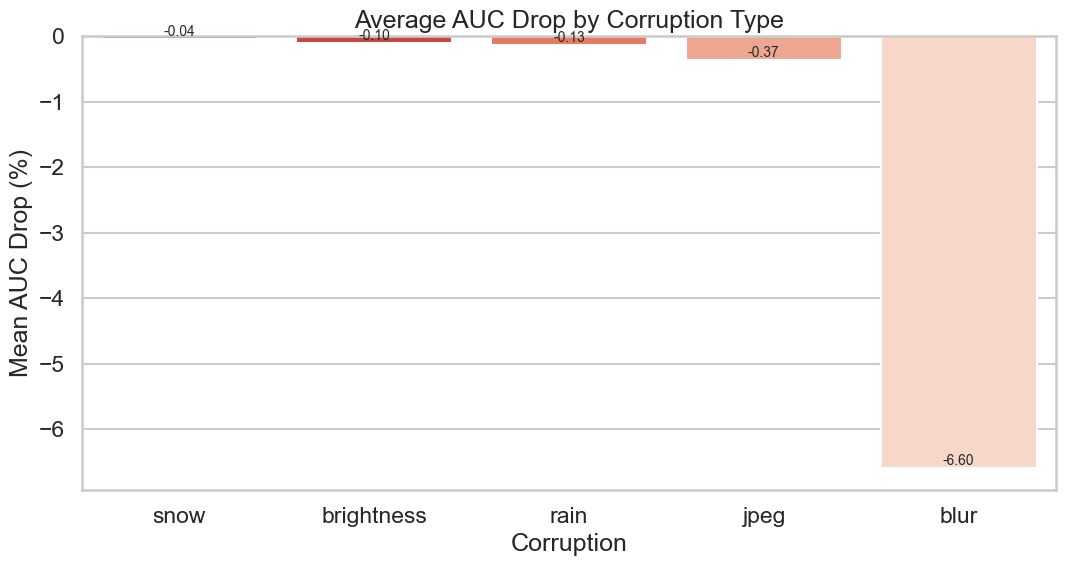

In [40]:
# 1) Corruption impact ranking (bar chart)
rank_plot_df = impact_rank_df.copy().sort_values("mean_auc_drop_pct", ascending=False)

plt.figure()
ax = sns.barplot(data=rank_plot_df, x="corruption", y="mean_auc_drop_pct", palette="Reds_r")
ax.set_title("Average AUC Drop by Corruption Type")
ax.set_xlabel("Corruption")
ax.set_ylabel("Mean AUC Drop (%)")
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.tight_layout()
plt.show()

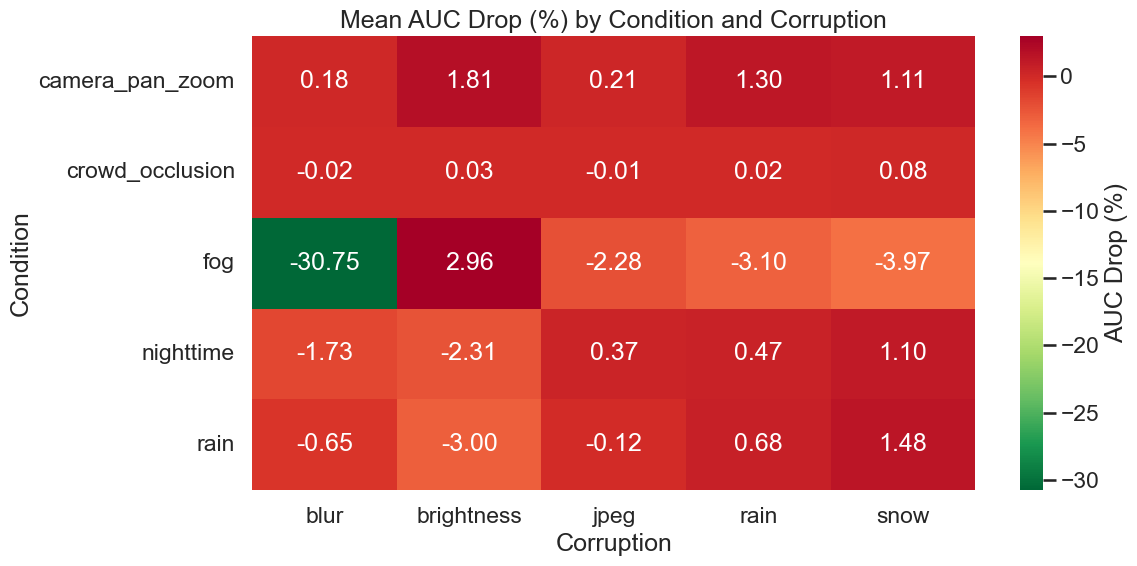

In [ ]:
# 2) Heatmap (condition x corruption) for AUC drop
heat_df = (
    individual_df.groupby(["condition", "corruption"], as_index=False)["auc_drop_pct_vs_clean"]
    .mean()
    .pivot(index="condition", columns="corruption", values="auc_drop_pct_vs_clean")
)

plt.figure(figsize=(12, 6))
sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="RdYlGn_r", cbar_kws={"label": "AUC Drop (%)"})
plt.title("Mean AUC Drop (%) by Condition and Corruption")
plt.xlabel("Corruption")
plt.ylabel("Condition")
plt.tight_layout()
plt.show()

/var/folders/n4/5mpnny3d2n5dqdtvgpbhfmdw0000gn/T/ipykernel_75726/3534814183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=individual_df, x="corruption", y="fpr_under_corruption", palette="Set2")


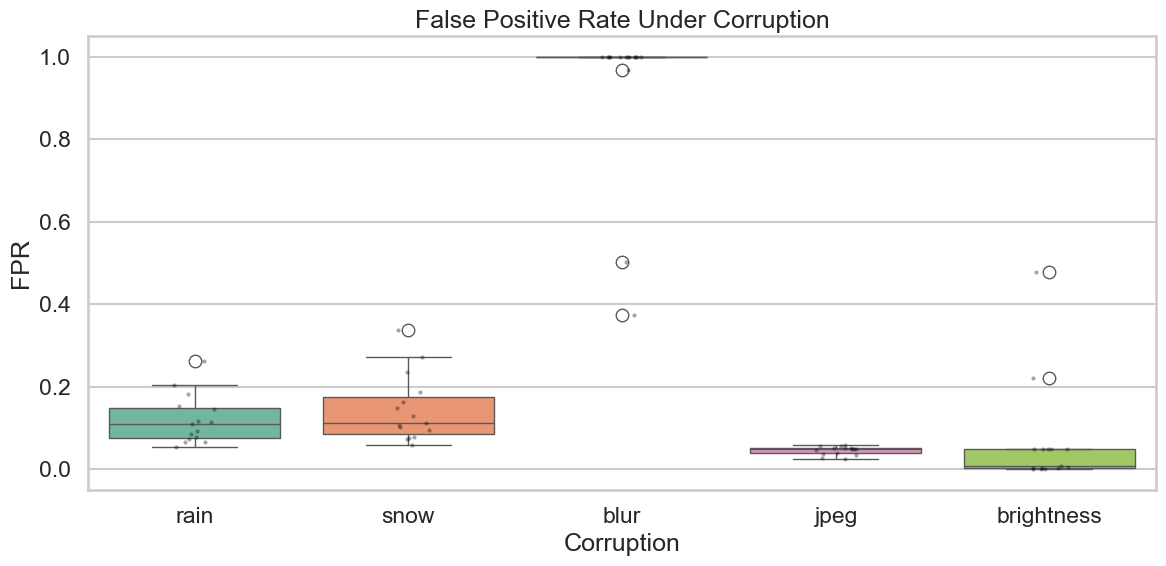

In [42]:
# 3) False-positive rate distribution under corruption
plt.figure(figsize=(12, 6))
sns.boxplot(data=individual_df, x="corruption", y="fpr_under_corruption", palette="Set2")
sns.stripplot(data=individual_df, x="corruption", y="fpr_under_corruption", color="black", alpha=0.35, size=3)
plt.title("False Positive Rate Under Corruption")
plt.xlabel("Corruption")
plt.ylabel("FPR")
plt.tight_layout()
plt.show()

/var/folders/n4/5mpnny3d2n5dqdtvgpbhfmdw0000gn/T/ipykernel_75726/2601548383.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=den_plot, x="combo", y="auc_recovery", palette="Blues_r")


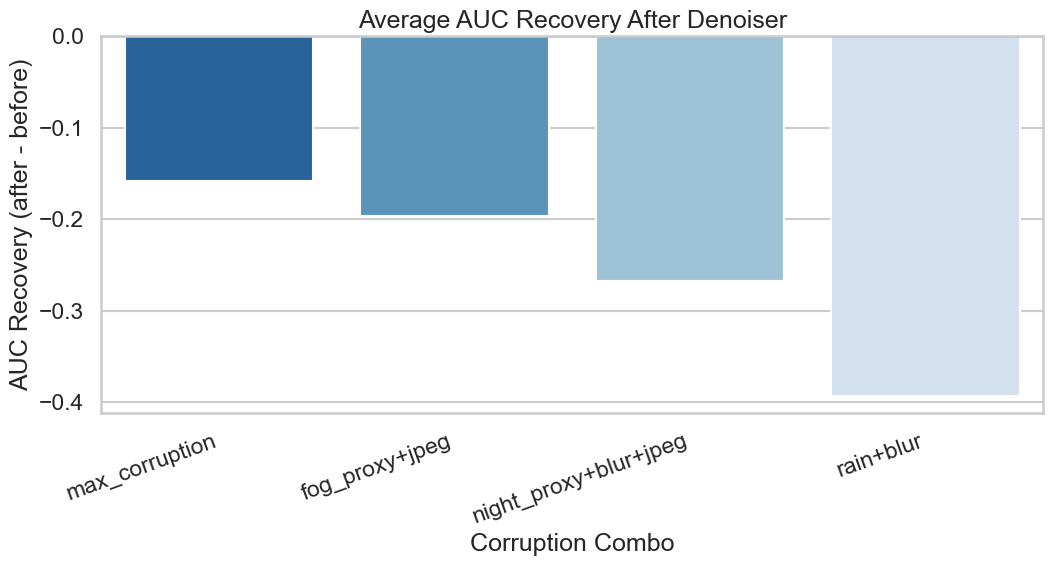

In [43]:
# 4) Denoiser recovery comparison
den_plot = (
    denoiser_df.groupby("combo", as_index=False)["auc_recovery"]
    .mean()
    .sort_values("auc_recovery", ascending=False)
)

plt.figure()
ax = sns.barplot(data=den_plot, x="combo", y="auc_recovery", palette="Blues_r")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Average AUC Recovery After Denoiser")
ax.set_xlabel("Corruption Combo")
ax.set_ylabel("AUC Recovery (after - before)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

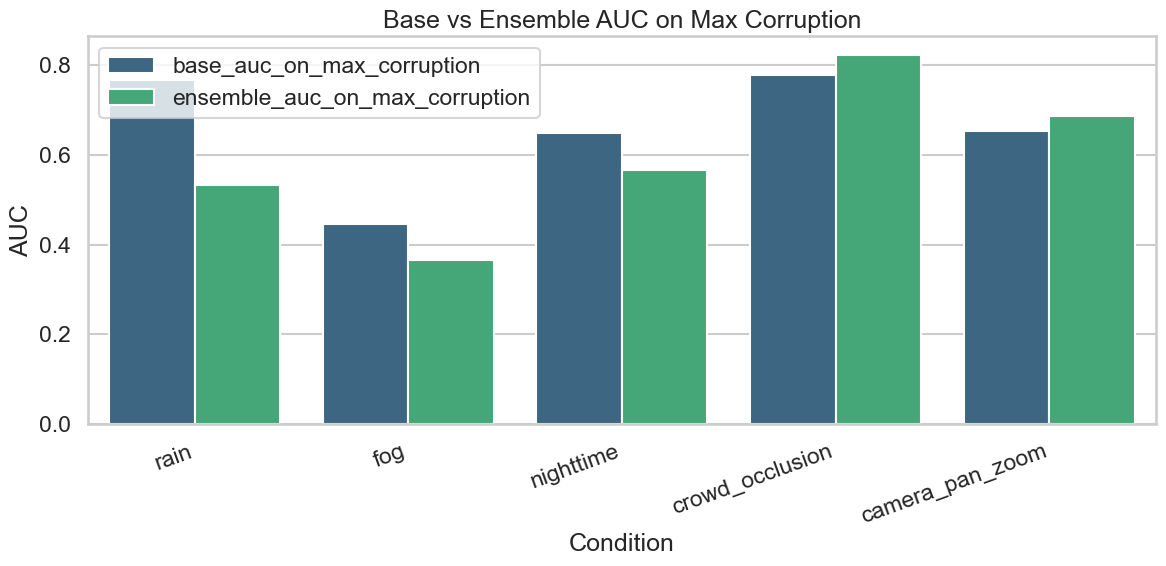

In [44]:
# 5) Base vs Ensemble on max corruption
ens_long = ensemble_df.melt(
    id_vars=["condition"],
    value_vars=["base_auc_on_max_corruption", "ensemble_auc_on_max_corruption"],
    var_name="model_type",
    value_name="auc",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=ens_long, x="condition", y="auc", hue="model_type", palette="viridis")
plt.title("Base vs Ensemble AUC on Max Corruption")
plt.xlabel("Condition")
plt.ylabel("AUC")
plt.xticks(rotation=20, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.show()

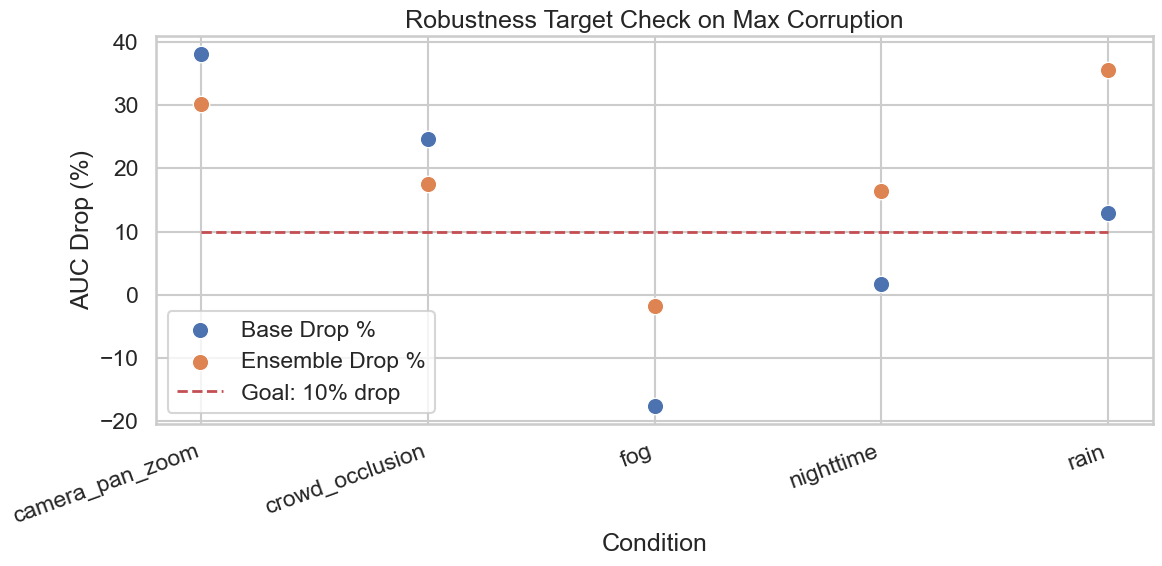

In [45]:
# 6) Robustness goal visualization (<10% drop)
bench_plot = benchmark_df.copy()
bench_plot["goal_line"] = 10.0

plt.figure(figsize=(12, 6))
sns.scatterplot(data=bench_plot, x="condition", y="base_drop_pct", s=140, label="Base Drop %")
sns.scatterplot(data=bench_plot, x="condition", y="ensemble_drop_pct", s=140, label="Ensemble Drop %")
plt.plot(bench_plot["condition"], bench_plot["goal_line"], "r--", linewidth=2, label="Goal: 10% drop")
plt.title("Robustness Target Check on Max Corruption")
plt.xlabel("Condition")
plt.ylabel("AUC Drop (%)")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()